In [1]:
%%capture
!pip install opencv-python-headless scikit-learn seaborn pillow

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [3]:
drive.mount('/content/drive')
print("Google Drive mounted!")

Mounted at /content/drive
Google Drive mounted!


In [8]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    for file in files:
        if file.endswith('.zip'):
            print(os.path.join(root, file))

/content/drive/MyDrive/Skincare Project/data set .zip
/content/drive/MyDrive/Skincare Project/data set 2.zip


In [10]:
import zipfile

# Skin type dataset unzipped
with zipfile.ZipFile('/content/drive/MyDrive/Skincare Project/data set .zip', 'r') as zip_ref:
    zip_ref.extractall('/content/skin_types')

# Cosmetics dataset unzipped
with zipfile.ZipFile('/content/drive/MyDrive/Skincare Project/data set 2.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/cosmetics')

print("Datasets unzipped!")

Datasets unzipped!


In [26]:
# The following checks skin type folders
print("=== SKIN TYPE DATASET ===")
for root, dirs, files in os.walk('/content/skin_types'):
    level = root.replace('/content/skin_types', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        print(f'{subindent}{len(files)} files')

# This one checks cosmetics files
print("\n=== COSMETICS DATASET ===")
for f in os.listdir('/content/cosmetics'):
    print(f)

=== SKIN TYPE DATASET ===
skin_types/
  0 files
  Oily-Dry-Skin-Types/
    1 files
    valid/
      oily/
      normal/
      dry/
    train/
      oily/
      normal/
      dry/
    test/
      oily/
      normal/
      dry/

=== COSMETICS DATASET ===
cosmetics.csv


In [29]:
def style_table(df, title=""):
    df = df.copy()
    for col in df.select_dtypes(include='number').columns:
        df[col] = df[col].round(2)
    df.columns = [col.replace('_', ' ').title() for col in df.columns]
    display(HTML(f'<h3 style="color:#9d174d; font-size:18px; font-weight:bold; padding:8px 0;">{title}</h3>'))
    styled = df.style\
        .hide(axis='index')\
        .set_properties(**{
            'font-size': '13px',
            'border': '1px solid #e9d5ff',
            'text-align': 'center',
            'padding': '10px 16px',
            'background-color': '#fdf4ff',
            'color': '#3b0764'
        })\
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('background-color', '#c084fc'),
                ('color', 'white'),
                ('font-size', '13px'),
                ('font-weight', 'bold'),
                ('padding', '10px 16px'),
                ('border', '1px solid #e9d5ff')
            ]},
            {'selector': 'tr:nth-child(even) td', 'props': [
                ('background-color', '#f3e8ff'),
            ]},
            {'selector': 'tr:hover td', 'props': [
                ('background-color', '#f9a8d4 !important'),
            ]}
        ])
    return styled

In [30]:
import glob
csv_files = glob.glob('/content/cosmetics/**/*.csv', recursive=True)
print("CSV files found:", csv_files)

df_products = pd.read_csv(csv_files[0])
print(f"\nLoaded {len(df_products)} products!")
print(df_products.head())
print("\nColumns:", df_products.columns.tolist())

CSV files found: ['/content/cosmetics/cosmetics.csv']

Loaded 1472 products!
         Label           Brand                                           Name  \
0  Moisturizer          LA MER                                Crème de la Mer   
1  Moisturizer           SK-II                       Facial Treatment Essence   
2  Moisturizer  DRUNK ELEPHANT                     Protini™ Polypeptide Cream   
3  Moisturizer          LA MER                    The Moisturizing Soft Cream   
4  Moisturizer    IT COSMETICS  Your Skin But Better™ CC+™ Cream with SPF 50+   

   Price  Rank                                        Ingredients  \
0    175   4.1  Algae (Seaweed) Extract, Mineral Oil, Petrolat...   
1    179   4.1  Galactomyces Ferment Filtrate (Pitera), Butyle...   
2     68   4.4  Water, Dicaprylyl Carbonate, Glycerin, Ceteary...   
3    175   3.8  Algae (Seaweed) Extract, Cyclopentasiloxane, P...   
4     38   4.1  Water, Snail Secretion Filtrate, Phenyl Trimet...   

   Combination  Dry  

In [31]:
print("=== PRODUCT CATEGORIES ===")
print(df_products['Label'].value_counts())

print("\n=== SKIN TYPE COLUMNS ===")
skin_cols = [col for col in df_products.columns if col in ['Combination', 'Dry', 'Normal', 'Oily', 'Sensitive']]
print(skin_cols)
print(df_products[skin_cols].head(10))

=== PRODUCT CATEGORIES ===
Label
Moisturizer    298
Cleanser       281
Face Mask      266
Treatment      248
Eye cream      209
Sun protect    170
Name: count, dtype: int64

=== SKIN TYPE COLUMNS ===
['Combination', 'Dry', 'Normal', 'Oily', 'Sensitive']
   Combination  Dry  Normal  Oily  Sensitive
0            1    1       1     1          1
1            1    1       1     1          1
2            1    1       1     1          0
3            1    1       1     1          1
4            1    1       1     1          1
5            1    0       1     1          1
6            1    1       1     1          0
7            1    1       1     1          0
8            1    1       1     1          1
9            0    0       0     0          0


In [32]:
skin_dirs = {}
for root, dirs, files in os.walk('/content/skin_types'):
    for d in dirs:
        if d.lower() in ['oily', 'dry', 'normal']:
            skin_dirs[d.lower()] = os.path.join(root, d)

print("Skin type directories found:")
for skin_type, path in skin_dirs.items():
    count = len(os.listdir(path))
    print(f"  {skin_type}: {count} images")

Skin type directories found:
  oily: 40 images
  normal: 59 images
  dry: 35 images


In [33]:
def extract_skin_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    texture_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    smoothness_score = round(100 - min(texture_score / 10, 100), 2)

    r, g, b = img_resized[:,:,0], img_resized[:,:,1], img_resized[:,:,2]
    pigmentation_score = round(float(np.std(r) + np.std(g) + np.std(b)) / 3, 2)
    redness_score = round(float(np.mean(r) / (np.mean(g) + np.mean(b) + 1e-6) * 100), 2)
    brightness = round(float(np.mean(gray)), 2)

    blur = cv2.GaussianBlur(gray, (5,5), 0)
    pore_score = round(float(np.mean(np.abs(gray.astype(float) - blur.astype(float)))), 2)

    health_score = round(
        (smoothness_score * 0.3) +
        (max(0, 100 - pigmentation_score) * 0.3) +
        (max(0, 100 - redness_score * 10) * 0.2) +
        (min(brightness / 2.55, 100) * 0.2), 2
    )

    return {
        'texture_score': round(texture_score, 2),
        'smoothness_score': smoothness_score,
        'pigmentation_score': pigmentation_score,
        'redness_score': redness_score,
        'brightness': brightness,
        'pore_score': pore_score,
        'health_score': health_score
    }

print("Feature extraction function ready!")

Feature extraction function ready!


In [34]:
all_features = []

for skin_type, folder_path in skin_dirs.items():
    print(f"Processing {skin_type} skin images...")
    images = os.listdir(folder_path)[:50]

    for img_name in images:
        img_path = os.path.join(folder_path, img_name)
        features = extract_skin_features(img_path)
        if features:
            features['skin_type'] = skin_type
            features['image_name'] = img_name
            all_features.append(features)

    print(f"  Processed {len(images)} images!")

df_features = pd.DataFrame(all_features)
print(f"\nTotal images processed: {len(df_features)}")
print(df_features.head())

Processing oily skin images...
  Processed 40 images!
Processing normal skin images...
  Processed 50 images!
Processing dry skin images...
  Processed 35 images!

Total images processed: 125
   texture_score  smoothness_score  pigmentation_score  redness_score  \
0         249.92             75.01               68.60          85.41   
1         467.50             53.25               87.42          62.50   
2        1949.84              0.00              102.98          60.34   
3        1856.52              0.00              100.16          59.46   
4        1574.65              0.00               55.79          66.69   

   brightness  pore_score  health_score skin_type  \
0       78.61        2.24         38.09      oily   
1      115.21        2.78         28.79      oily   
2      112.10        4.19          8.79      oily   
3      147.45        4.61         11.56      oily   
4      132.37        5.53         23.64      oily   

                                          image_na

In [17]:
from IPython.display import display, HTML

summary = df_features.groupby('skin_type').agg(
    avg_smoothness=('smoothness_score', 'mean'),
    avg_pigmentation=('pigmentation_score', 'mean'),
    avg_redness=('redness_score', 'mean'),
    avg_pores=('pore_score', 'mean'),
    avg_health=('health_score', 'mean'),
    total_images=('image_name', 'count')
).round(2).reset_index()

def style_table(df, title=""):
    df = df.copy()
    df.columns = [col.replace('_', ' ').title() for col in df.columns]
    display(HTML(f'<h3 style="color:#9d174d; font-size:18px; font-weight:bold; padding:8px 0;">{title}</h3>'))
    styled = df.style\
        .hide(axis='index')\
        .set_properties(**{
            'font-size': '13px',
            'border': '1px solid #e9d5ff',
            'text-align': 'center',
            'padding': '10px 16px',
            'background-color': '#fdf4ff',
            'color': '#3b0764'
        })\
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('background-color', '#c084fc'),
                ('color', 'white'),
                ('font-size', '13px'),
                ('font-weight', 'bold'),
                ('padding', '10px 16px'),
                ('border', '1px solid #e9d5ff')
            ]},
            {'selector': 'tr:nth-child(even) td', 'props': [
                ('background-color', '#f3e8ff'),
            ]},
            {'selector': 'tr:hover td', 'props': [
                ('background-color', '#f9a8d4 !important'),
            ]}
        ])
    return styled

display(style_table(summary, "Skin Type Analysis Summary"))

Skin Type,Avg Smoothness,Avg Pigmentation,Avg Redness,Avg Pores,Avg Health,Total Images
dry,13.810000,78.850000,62.050000,4.120000,18.850000,35
normal,17.570000,84.110000,59.340000,3.870000,19.000000,50
oily,19.200000,78.670000,64.590000,3.810000,21.050000,40


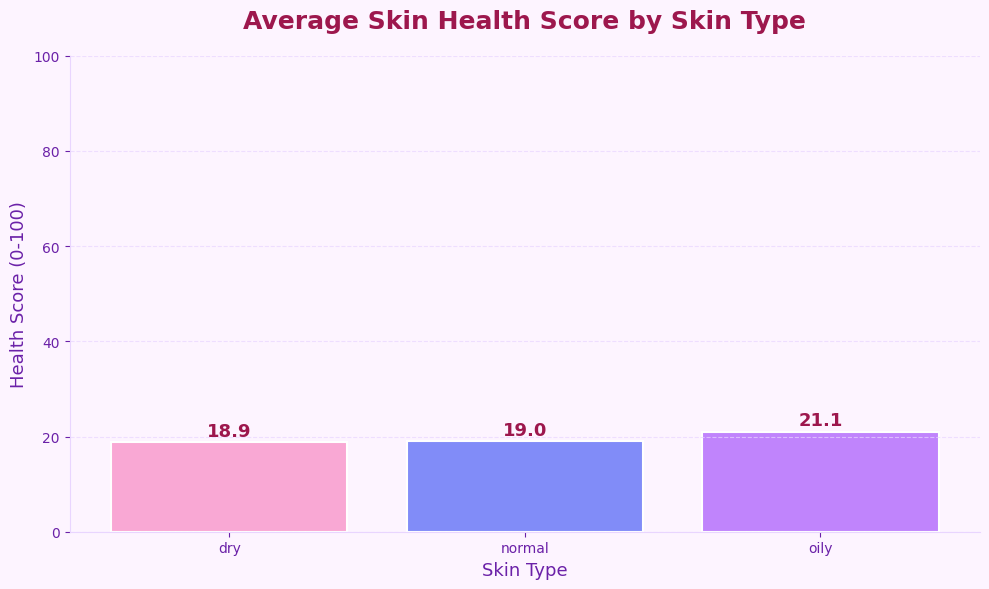

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'oily': '#c084fc', 'dry': '#f9a8d4', 'normal': '#818cf8'}
skin_colors = [colors.get(s, '#c084fc') for s in summary['skin_type']]

bars = ax.bar(summary['skin_type'], summary['avg_health'],
              color=skin_colors, edgecolor='white', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}', ha='center', va='bottom',
            fontsize=13, fontweight='bold', color='#9d174d')

ax.set_title('Average Skin Health Score by Skin Type',
             fontsize=18, fontweight='bold', color='#9d174d', pad=20)
ax.set_xlabel('Skin Type', fontsize=13, color='#6b21a8')
ax.set_ylabel('Health Score (0-100)', fontsize=13, color='#6b21a8')
ax.set_ylim(0, 100)
ax.set_facecolor('#fdf4ff')
fig.patch.set_facecolor('#fdf4ff')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#e9d5ff')
ax.spines['bottom'].set_color('#e9d5ff')
ax.yaxis.grid(True, color='#e9d5ff', linestyle='--', alpha=0.7)
ax.tick_params(colors='#6b21a8')
plt.tight_layout()
plt.savefig('health_by_skin_type.png', dpi=150, bbox_inches='tight')
plt.show()

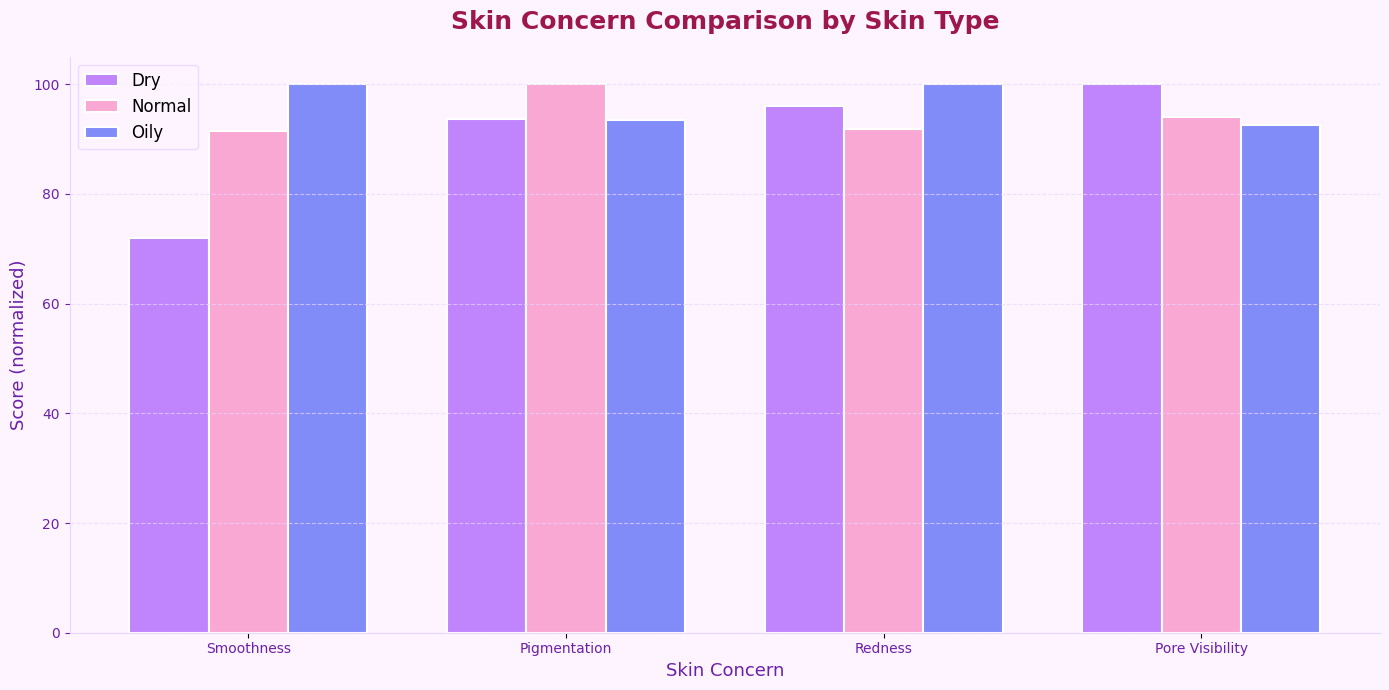

In [19]:
metrics = ['avg_smoothness', 'avg_pigmentation', 'avg_redness', 'avg_pores']
metric_labels = ['Smoothness', 'Pigmentation', 'Redness', 'Pore Visibility']

x = np.arange(len(metric_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
skin_types = summary['skin_type'].tolist()
bar_colors = ['#c084fc', '#f9a8d4', '#818cf8']

for i, (skin, color) in enumerate(zip(skin_types, bar_colors)):
    row = summary[summary['skin_type'] == skin].iloc[0]
    values = [row[m] for m in metrics]
    max_vals = [summary[m].max() for m in metrics]
    normalized = [v/m*100 if m > 0 else 0 for v, m in zip(values, max_vals)]
    ax.bar(x + i*width, normalized, width,
           label=skin.title(), color=color,
           edgecolor='white', linewidth=1.5)

ax.set_title('Skin Concern Comparison by Skin Type',
             fontsize=18, fontweight='bold', color='#9d174d', pad=20)
ax.set_xlabel('Skin Concern', fontsize=13, color='#6b21a8')
ax.set_ylabel('Score (normalized)', fontsize=13, color='#6b21a8')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, color='#6b21a8')
ax.tick_params(axis='y', colors='#6b21a8')
ax.legend(fontsize=12, facecolor='#fdf4ff', edgecolor='#e9d5ff')
ax.set_facecolor('#fdf4ff')
fig.patch.set_facecolor('#fdf4ff')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#e9d5ff')
ax.spines['bottom'].set_color('#e9d5ff')
ax.yaxis.grid(True, color='#e9d5ff', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('skin_concern_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

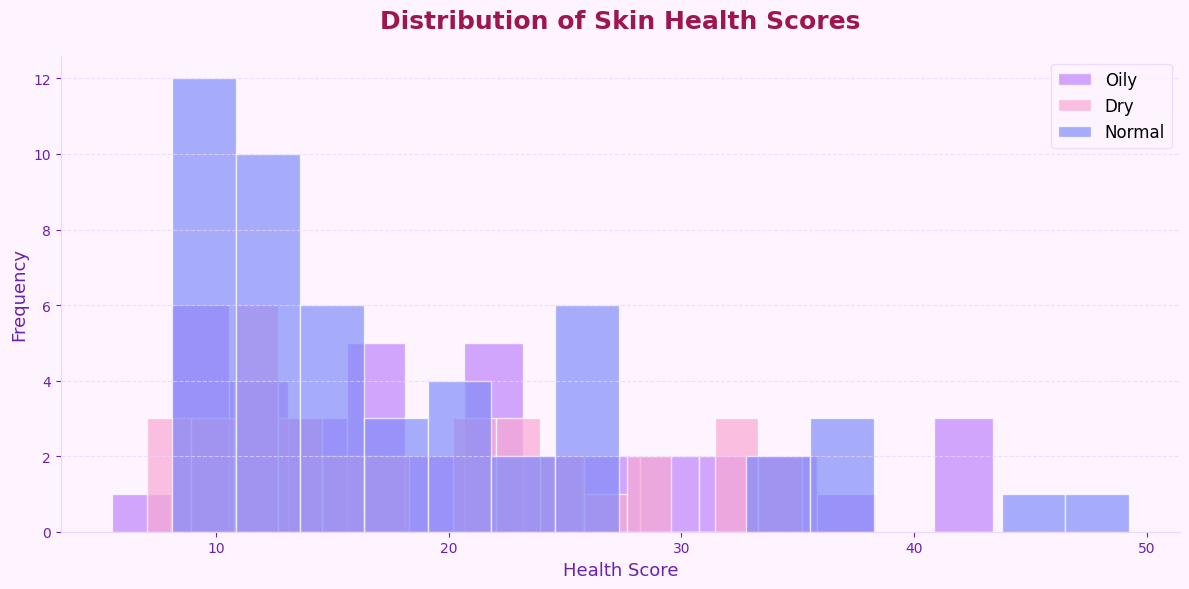

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = {'oily': '#c084fc', 'dry': '#f9a8d4', 'normal': '#818cf8'}

for skin_type, color in colors.items():
    if skin_type in df_features['skin_type'].values:
        data = df_features[df_features['skin_type'] == skin_type]['health_score']
        ax.hist(data, bins=15, alpha=0.7, color=color,
                label=skin_type.title(), edgecolor='white')

ax.set_title('Distribution of Skin Health Scores',
             fontsize=18, fontweight='bold', color='#9d174d', pad=20)
ax.set_xlabel('Health Score', fontsize=13, color='#6b21a8')
ax.set_ylabel('Frequency', fontsize=13, color='#6b21a8')
ax.legend(fontsize=12, facecolor='#fdf4ff', edgecolor='#e9d5ff')
ax.set_facecolor('#fdf4ff')
fig.patch.set_facecolor('#fdf4ff')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#e9d5ff')
ax.spines['bottom'].set_color('#e9d5ff')
ax.tick_params(colors='#6b21a8')
ax.yaxis.grid(True, color='#e9d5ff', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('health_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

feature_cols = ['texture_score', 'smoothness_score', 'pigmentation_score',
                'redness_score', 'brightness', 'pore_score']

X = df_features[feature_cols]
y = df_features['skin_type']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy = clf.score(X_test, y_test)
print(f"Model Accuracy: {accuracy*100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Model Accuracy: 32.0%

Classification Report:
              precision    recall  f1-score   support

         dry       0.00      0.00      0.00         7
      normal       0.29      0.50      0.36         8
        oily       0.50      0.40      0.44        10

    accuracy                           0.32        25
   macro avg       0.26      0.30      0.27        25
weighted avg       0.29      0.32      0.29        25



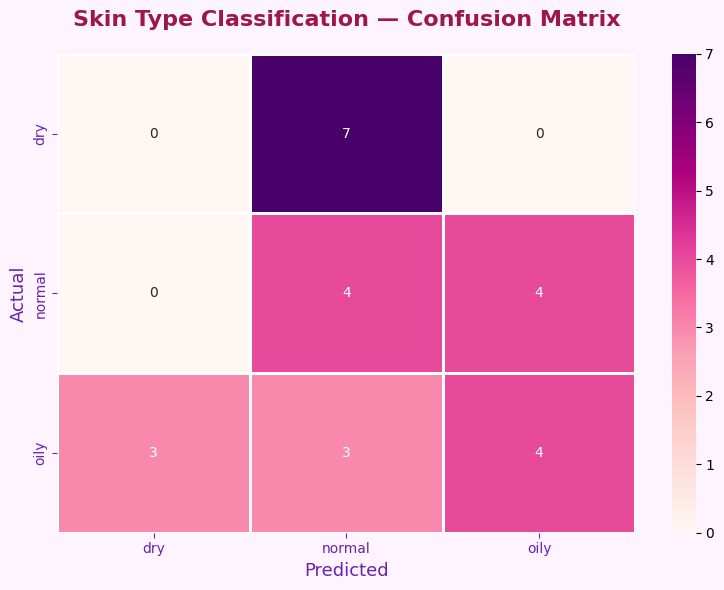

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='RdPu', ax=ax,
            linewidths=1, linecolor='white')

ax.set_title('Skin Type Classification — Confusion Matrix',
             fontsize=16, fontweight='bold', color='#9d174d', pad=20)
ax.set_xlabel('Predicted', fontsize=13, color='#6b21a8')
ax.set_ylabel('Actual', fontsize=13, color='#6b21a8')
ax.tick_params(colors='#6b21a8')
fig.patch.set_facecolor('#fdf4ff')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
def recommend_products(skin_type, top_n=5):
    skin_map = {'oily': 'Oily', 'dry': 'Dry', 'normal': 'Normal'}
    skin_col = skin_map.get(skin_type.lower(), 'Normal')

    # Filters by skin type:
    if skin_col in df_products.columns:
        recommended = df_products[df_products[skin_col] == 1].copy()
        # If not enough results fall back to all products
        if len(recommended) < top_n:
            recommended = df_products.copy()
    else:
        recommended = df_products.copy()

    # Sorts by rank if available:
    if 'Rank' in recommended.columns:
        recommended = recommended.sort_values('Rank', ascending=False)

    cols = ['Label', 'Brand', 'Name', 'Price', 'Rank']
    available_cols = [c for c in cols if c in recommended.columns]

    # Make sure each skin type gets different products by shuffling differently
    recommended = recommended.sample(frac=1, random_state=hash(skin_type) % 100)

    return recommended[available_cols].head(top_n).reset_index(drop=True)

display(style_table(recommend_products('oily'), "Top Products for Oily Skin"))
display(style_table(recommend_products('dry'), "Top Products for Dry Skin"))
display(style_table(recommend_products('normal'), "Top Products for Normal Skin"))

Label,Brand,Name,Price,Rank
Face Mask,BELIF,Pore Cleaner Bubble Foam,36,4.400000
Moisturizer,MURAD,Nutrient-Charged Water Gel,60,4.600000
Moisturizer,SON & PARK,Beauty Water,30,4.600000
Eye cream,CLINIQUE,All About Eyes™ Rich,32,4.200000
Moisturizer,MILK MAKEUP,Cooling Water,24,3.800000


Label,Brand,Name,Price,Rank
Sun protect,KIEHL'S SINCE 1851,Super Multi-Corrective Cream Sunscreen Broad Spectrum SPF 30,84,3.500000
Treatment,JOSIE MARAN,Pure Argan Milk™ Intensive Hydrating Treatment,56,4.000000
Cleanser,ERNO LASZLO,Pore Refining Detox Double Cleanse,55,5.000000
Cleanser,CLARISONIC,Refreshing Gel Cleanser,19,5.000000
Moisturizer,MURAD,Retinol Youth Renewal Night Cream,82,4.600000


Label,Brand,Name,Price,Rank
Face Mask,DIOR,Hydra Life Glow Better Fresh Jelly Mask,69,4.300000
Treatment,BIOEFFECT,EGF Serum,160,5.000000
Cleanser,PERRICONE MD,PRE:EMPT SERIES™ Exfoliating Pore Refiner,45,4.500000
Face Mask,GLAMGLOW,GLAMGLOW x MY LITTLE PONY® #GLITTERMASK GRAVITYMUD™ Firming Treatment,59,3.900000
Cleanser,KIEHL'S SINCE 1851,Ultra Facial Oil-Free Cleanser,20,4.200000


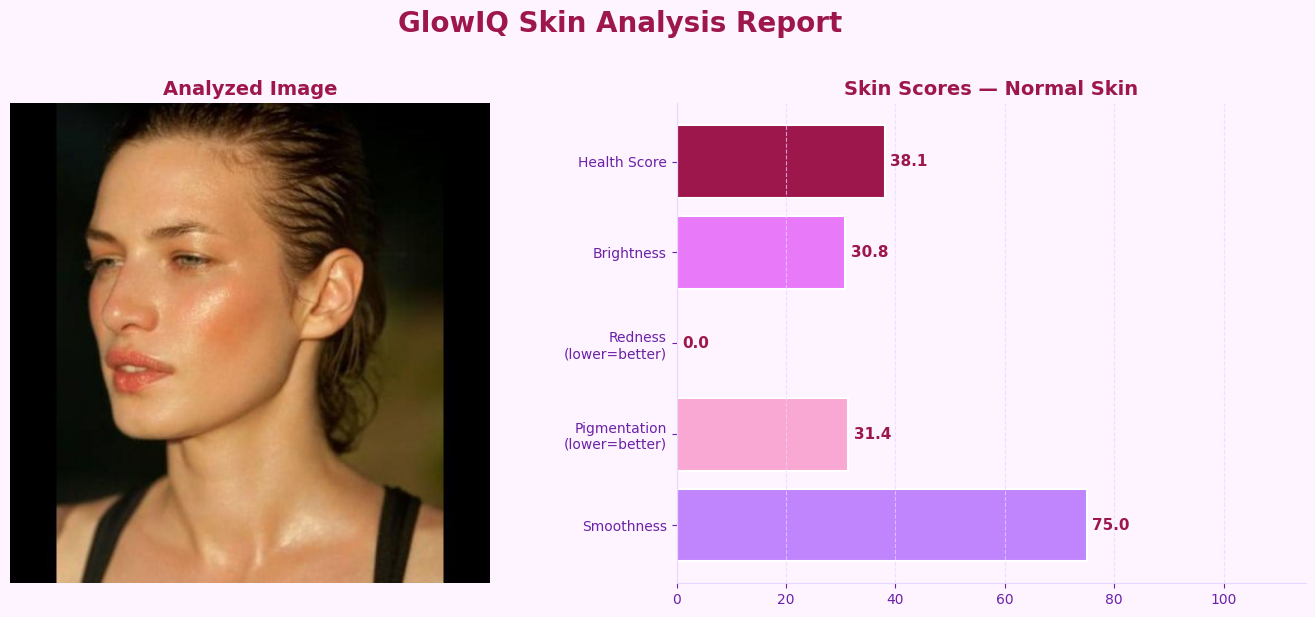


SKIN TYPE DETECTED: NORMAL
OVERALL HEALTH SCORE: 38.09/100
Smoothness:    75.0/100
Pigmentation:  68.6
Redness:       85.4
Brightness:    78.6
Pore Score:    2.2

RECOMMENDED PRODUCTS FOR NORMAL SKIN:


Label,Brand,Name,Price,Rank
Moisturizer,LA MER,Crème de la Mer,175,4.100000
Moisturizer,SK-II,Facial Treatment Essence,179,4.100000
Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.400000
Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.800000
Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.100000


In [24]:
def generate_skin_report(image_path):
    features = extract_skin_features(image_path)
    if not features:
        print("Could not process image!")
        return

    feature_vals = [[
        features['texture_score'],
        features['smoothness_score'],
        features['pigmentation_score'],
        features['redness_score'],
        features['brightness'],
        features['pore_score']
    ]]

    predicted_encoded = clf.predict(feature_vals)[0]
    predicted_skin_type = le.inverse_transform([predicted_encoded])[0]

    img = Image.open(image_path)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('#fdf4ff')

    axes[0].imshow(img)
    axes[0].set_title('Analyzed Image',
                      fontsize=14, fontweight='bold', color='#9d174d')
    axes[0].axis('off')

    score_names = ['Smoothness', 'Pigmentation\n(lower=better)',
                   'Redness\n(lower=better)', 'Brightness', 'Health Score']
    score_values = [
        features['smoothness_score'],
        max(0, 100 - features['pigmentation_score']),
        max(0, 100 - features['redness_score'] * 10),
        min(features['brightness'] / 2.55, 100),
        features['health_score']
    ]

    bar_colors = ['#c084fc', '#f9a8d4', '#818cf8', '#e879f9', '#9d174d']
    bars = axes[1].barh(score_names, score_values,
                        color=bar_colors, edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, score_values):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}', va='center', fontsize=11,
                     fontweight='bold', color='#9d174d')

    axes[1].set_title(f'Skin Scores — {predicted_skin_type.title()} Skin',
                      fontsize=14, fontweight='bold', color='#9d174d')
    axes[1].set_xlim(0, 115)
    axes[1].set_facecolor('#fdf4ff')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].spines['left'].set_color('#e9d5ff')
    axes[1].spines['bottom'].set_color('#e9d5ff')
    axes[1].tick_params(colors='#6b21a8')
    axes[1].xaxis.grid(True, color='#e9d5ff', linestyle='--', alpha=0.7)

    plt.suptitle('GlowIQ Skin Analysis Report',
                 fontsize=20, fontweight='bold', color='#9d174d', y=1.02)
    plt.tight_layout()
    plt.savefig('skin_report.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n{'='*40}")
    print(f"SKIN TYPE DETECTED: {predicted_skin_type.upper()}")
    print(f"OVERALL HEALTH SCORE: {features['health_score']}/100")
    print(f"{'='*40}")
    print(f"Smoothness:    {features['smoothness_score']:.1f}/100")
    print(f"Pigmentation:  {features['pigmentation_score']:.1f}")
    print(f"Redness:       {features['redness_score']:.1f}")
    print(f"Brightness:    {features['brightness']:.1f}")
    print(f"Pore Score:    {features['pore_score']:.1f}")

    print(f"\nRECOMMENDED PRODUCTS FOR {predicted_skin_type.upper()} SKIN:")
    recs = recommend_products(predicted_skin_type, top_n=5)
    display(style_table(recs, f"Recommended Products for {predicted_skin_type.title()} Skin"))

# Run on a sample image
sample_skin_type = list(skin_dirs.keys())[0]
sample_folder = skin_dirs[sample_skin_type]
sample_image = os.path.join(sample_folder, os.listdir(sample_folder)[0])
generate_skin_report(sample_image)